# Accessing Open Geospatial Embeddings

This tutorial walks through how to access, inspect, and fetch geospatial embedding data from a public cloud-hosted dataset.

### What are geospatial embeddings?

Geospatial embeddings are compact numerical vectors that represent satellite imagery. A pretrained model encodes each image (or patch, or pixel) into a fixed-length vector that captures its visual and spectral content. These embeddings can be used for downstream tasks like land-cover classification, change detection, or similarity search -- without reprocessing the raw imagery.

### The dataset: Alpha Earth Foundations

[Alpha Earth Foundations](https://arxiv.org/abs/2507.22291) is a project from Google that produced embeddings for satellite imagery at global scale and released them publicly on Google Cloud Storage. The dataset used in this tutorial is a reprocessed copy stored in [GeoZarr](https://geozarr.org/) format -- a cloud-native, chunked array format designed for geospatial data. The full collection is over **3 Petabytes**.

### Where is it hosted?

The data lives on [Source Cooperative](https://source.coop/) (Source Coop), an open data hosting platform backed by S3-compatible cloud storage. Source Coop provides free, anonymous access to many geospatial datasets -- no account or API key required to read the data.

### Key libraries

- **[Xarray](https://docs.xarray.dev/)** -- A Python library for working with labelled, multi-dimensional arrays. It lets you select data by coordinate name (e.g. latitude, longitude) instead of raw index numbers, which makes geospatial analysis much more intuitive.
- **[zarr-python](https://zarr.readthedocs.io/)** -- The underlying library that reads and writes Zarr stores. Zarr is a chunked, compressed array format designed for cloud storage -- data is split into small pieces so you can read just the region you need without downloading the whole file.
- **[GeoZarr](https://geozarr.org/)** -- A convention on top of Zarr that adds geospatial metadata: coordinate reference systems, spatial coordinates, and other information needed to place array data on a map.

Xarray uses zarr-python under the hood, so you typically just call `xr.open_zarr()` and both libraries work together.

### Running this notebook

```bash
uv run jupyter lab
```

In [1]:
import xarray as xr

STORE = 's3://us-west-2.opendata.source.coop/tge-labs/aef-mosaic/'

In [2]:
import warnings
from zarr.errors import ZarrUserWarning

warnings.simplefilter('ignore', ZarrUserWarning)
ds = xr.open_zarr(STORE, storage_options={'anon': True}, consolidated=False)

The full xarray `Dataset` is the top-level container. It shows the available variables, dimensions, and coordinates.

In [3]:
ds

<xarray.Dataset> Size: 3PB
Dimensions:     (time: 7, embedding: 64, y: 1859584, x: 4009984)
Coordinates:
  * time        (time) int32 28B 2018 2019 2020 2021 2022 2023 2024
  * y           (y) float64 15MB 83.69 83.69 83.69 ... -83.36 -83.36 -83.36
  * x           (x) float64 32MB -180.0 -180.0 -180.0 ... 180.2 180.2 180.2
Dimensions without coordinates: embedding
Data variables:
    embeddings  (time, embedding, y, x) int8 3PB ...

Variables in an xarray `Dataset` are `DataArray` objects: labeled n-dimensional arrays. This store has one main variable named `embeddings`.

In [4]:
ds.data_vars

Data variables:
    embeddings  (time, embedding, y, x) int8 3PB ...

In [5]:
ds['embeddings']

<xarray.DataArray 'embeddings' (time: 7, embedding: 64, y: 1859584, x: 4009984)> Size: 3PB
[3340692134821888 values with dtype=int8]
Coordinates:
  * time     (time) int32 28B 2018 2019 2020 2021 2022 2023 2024
  * y        (y) float64 15MB 83.69 83.69 83.69 83.69 ... -83.36 -83.36 -83.36
  * x        (x) float64 32MB -180.0 -180.0 -180.0 -180.0 ... 180.2 180.2 180.2
Dimensions without coordinates: embedding
Attributes:
    proj:code:               EPSG:4326
    spatial:dimensions:      ['y', 'x']
    spatial:transform:       [8.983111749910169e-05, 0.0, -180.0, 0.0, -8.983...
    spatial:transform_type:  affine
    spatial:bbox:            [-180.0, -83.36280346631479, 180.2213438735178, ...
    spatial:shape:           [1859584, 4009984]
    spatial:registration:    pixel
    embedding_dimensions:    ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06'...
    zarr_conventions:        [{'uuid': 'f17cb550-5864-4468-aeb7-f3180cfb622f'...
    _zarrs:                  {'description': 'This array was created with zar...

Dimensions are the axis names and their lengths. Here, `time`, `embedding`, `y`, and `x` define the positional structure of the array.

In [6]:
ds.dims

FrozenMappingWarningOnValuesAccess({'time': 7, 'embedding': 64, 'y': 1859584, 'x': 4009984})

Coordinates give semantic labels for positional axes. In this dataset, `time`, `x`, and `y` are explicit coordinate arrays.

In [7]:
ds.coords

Coordinates:
  * time     (time) int32 28B 2018 2019 2020 2021 2022 2023 2024
  * y        (y) float64 15MB 83.69 83.69 83.69 83.69 ... -83.36 -83.36 -83.36
  * x        (x) float64 32MB -180.0 -180.0 -180.0 -180.0 ... 180.2 180.2 180.2

In [8]:
ds.coords['time']

<xarray.DataArray 'time' (time: 7)> Size: 28B
array([2018, 2019, 2020, 2021, 2022, 2023, 2024], dtype=int32)
Coordinates:
  * time     (time) int32 28B 2018 2019 2020 2021 2022 2023 2024
Attributes:
    _zarrs:   {'description': 'This array was created with zarrs', 'repositor...

In [9]:
ds.coords['x']

<xarray.DataArray 'x' (x: 4009984)> Size: 32MB
array([-179.999955, -179.999865, -179.999775, ...,  180.221119,  180.221209,
        180.221299], shape=(4009984,))
Coordinates:
  * x        (x) float64 32MB -180.0 -180.0 -180.0 -180.0 ... 180.2 180.2 180.2
Attributes:
    _zarrs:   {'description': 'This array was created with zarrs', 'repositor...

In [10]:
ds.coords['y']

<xarray.DataArray 'y' (y: 1859584)> Size: 15MB
array([ 83.68566 ,  83.685571,  83.685481, ..., -83.362579, -83.362669,
       -83.362759], shape=(1859584,))
Coordinates:
  * y        (y) float64 15MB 83.69 83.69 83.69 83.69 ... -83.36 -83.36 -83.36
Attributes:
    _zarrs:   {'description': 'This array was created with zarrs', 'repositor...

`Dataset` attrs are metadata attached to the dataset object itself. In this store, the dataset-level attrs are empty, and the geospatial metadata lives on the `embeddings` `DataArray`.

In [11]:
ds['embeddings'].attrs

{'proj:code': 'EPSG:4326',
 'spatial:dimensions': ['y', 'x'],
 'spatial:transform': [8.983111749910169e-05,
  0.0,
  -180.0,
  0.0,
  -8.983111749910169e-05,
  83.68570533713473],
 'spatial:transform_type': 'affine',
 'spatial:bbox': [-180.0,
  -83.36280346631479,
  180.2213438735178,
  83.68570533713473],
 'spatial:shape': [1859584, 4009984],
 'spatial:registration': 'pixel',
 'embedding_dimensions': ['A00',
  'A01',
  'A02',
  'A03',
  'A04',
  'A05',
  'A06',
  'A07',
  'A08',
  'A09',
  'A10',
  'A11',
  'A12',
  'A13',
  'A14',
  'A15',
  'A16',
  'A17',
  'A18',
  'A19',
  'A20',
  'A21',
  'A22',
  'A23',
  'A24',
  'A25',
  'A26',
  'A27',
  'A28',
  'A29',
  'A30',
  'A31',
  'A32',
  'A33',
  'A34',
  'A35',
  'A36',
  'A37',
  'A38',
  'A39',
  'A40',
  'A41',
  'A42',
  'A43',
  'A44',
  'A45',
  'A46',
  'A47',
  'A48',
  'A49',
  'A50',
  'A51',
  'A52',
  'A53',
  'A54',
  'A55',
  'A56',
  'A57',
  'A58',
  'A59',
  'A60',
  'A61',
  'A62',
  'A63'],
 'zarr_conventions'

In [12]:
ds['embeddings'].attrs['embedding_dimensions'][:8]

['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07']

The primary geospatial metadata is attached to the `embeddings` `DataArray` attrs.

In [13]:
ds['embeddings'].attrs.keys()

dict_keys(['proj:code', 'spatial:dimensions', 'spatial:transform', 'spatial:transform_type', 'spatial:bbox', 'spatial:shape', 'spatial:registration', 'embedding_dimensions', 'zarr_conventions', '_zarrs'])

In [14]:
ds['embeddings'].attrs['proj:code']

'EPSG:4326'

In [15]:
ds['embeddings'].attrs['spatial:transform']

[8.983111749910169e-05,
 0.0,
 -180.0,
 0.0,
 -8.983111749910169e-05,
 83.68570533713473]

In [16]:
ds['embeddings'].attrs['spatial:bbox']

[-180.0, -83.36280346631479, 180.2213438735178, 83.68570533713473]

In [17]:
ds['embeddings'].attrs['spatial:shape']

[1859584, 4009984]

`spatial:transform` is the affine geotransform. It tells you pixel size, rotation terms, and the origin used to map array indices onto geographic space.

Xarray exposes this array as 256 x 256 logical chunks, but the store is physically written as 4096 x 4096 shards. A Zion bounding-box query spans many logical chunks and multiple shards, so a small `.sel(...)` can still fan out into a lot of IO. For a simpler low-level read, we can inspect the Zarr metadata first, then use zarr-python with an obstore-backed S3 client.

Warning: with `xarray.open_zarr(...)` on a sharded Zarr store, the `chunks=` argument effectively maps work onto the store's shard layout rather than letting you fetch individual inner chunks. That means the minimum array unit downloaded during `.compute()`, `.load()`, or plotting can be much larger than you expect, which is why visualization can feel slow even for a small spatial subset. For now, `zarr-python` is the simpler way to fetch chunk-level data from a sharded store directly. Xarray uses `zarr-python` under the hood, so this should improve as xarray gains better support for chunk-vs-shard reads in sharded Zarr stores.

In [18]:
import math

import zarr
from obstore.store import S3Store
from zarr.storage import ObjectStore

In [19]:
store = S3Store.from_url(STORE, skip_signature=True, region='us-west-2')
embeddings = zarr.open_group(store=ObjectStore(store, read_only=True), mode='r')['embeddings']

You can inspect chunking and sharding from metadata alone, without fetching array values.

In [20]:
{'shape': embeddings.shape, 'chunks': embeddings.chunks, 'shards': embeddings.shards}

{'shape': (7, 64, 1859584, 4009984),
 'chunks': (1, 64, 256, 256),
 'shards': (1, 64, 4096, 4096)}

A physical shard spans `(time, embedding, y, x) = (1, 64, 4096, 4096)`. If you slice `[0, 0, ...]`, you are fetching one time step, 64 embedding channels, and 4096 x 4096 height and width. The chunking scheme determines the minimum unit you can fetch in general. 

In [21]:
zion_lon = -113.03
zion_lat = 37.30
dx, _, x_origin, _, dy, y_origin = embeddings.attrs['spatial:transform']

x_index = math.floor((zion_lon - x_origin) / dx)
y_index = math.floor((zion_lat - y_origin) / dy)

x_chunk = x_index // embeddings.chunks[3]
y_chunk = y_index // embeddings.chunks[2]
x_shard = x_index // embeddings.shards[3]
y_shard = y_index // embeddings.shards[2]

In [22]:
x_chunk_start = x_chunk * embeddings.chunks[3]
y_chunk_start = y_chunk * embeddings.chunks[2]
x_shard_start = x_shard * embeddings.shards[3]
y_shard_start = y_shard * embeddings.shards[2]

This zarr-python example reads a single logical chunk around Zion.

In [23]:
zion_chunk = embeddings[
    0,
    :,
    y_chunk_start:y_chunk_start + embeddings.chunks[2],
    x_chunk_start:x_chunk_start + embeddings.chunks[3],
]
zion_chunk.shape

(64, 256, 256)

You can plot one embedding channel from that Zion chunk with `matplotlib.pyplot.imshow`. While this is not so interpretable, follow up tutorials will show how to use dimension reduction on embeddings to make sense of landscape features.

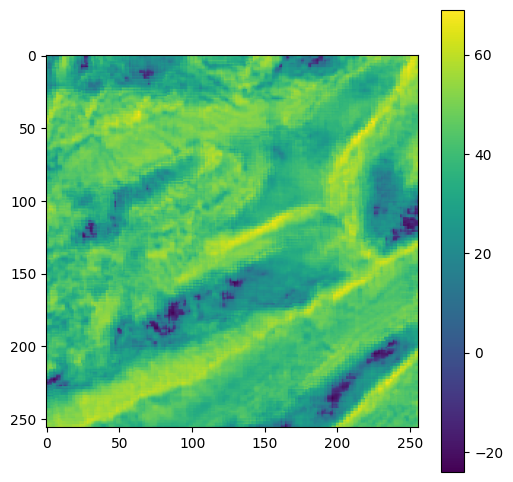

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(zion_chunk[0], cmap='viridis')
plt.colorbar()

Here is the equivalent xarray code to force a read of exactly one physical shard. Leave this cell unrun if you just want the example. For this array, one shard spans `(time, embedding, y, x) = (1, 64, 4096, 4096)`, so reading a full shard means pulling 64 embedding channels over a 4096 x 4096 spatial tile for one time step.

In [ ]:
(
    ds['embeddings']
    .isel(
        time=0,
        embedding=0,
        y=slice(y_shard_start, y_shard_start + embeddings.shards[2]),
        x=slice(x_shard_start, x_shard_start + embeddings.shards[3]),
    )
    .load()
)